<a href="https://colab.research.google.com/github/nthu-lab2-2025/Vibration_testing/blob/main/5_model_GRU0805_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import time  # 新增：計算推論時間

# ========================
# 參數設定
# ========================
SEQ_LEN = 64
BATCH_SIZE = 128
EPOCHS = 300

# 設定訓練設備（優先使用 GPU，如果可用）
#DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
#print(f"Using device: {DEVICE}")

# 設定訓練設備（優先使用 GPU，如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#DEVICE = "cpu"  # 強制使用 CPU

HIDDEN_SIZE = 128
NUM_LAYERS = 3
LR = 0.001
MODEL_TYPES = ["LSTM", "GRU", "RNN", "CNN", "CNN_LSTM"]

# ========================
# 資料預處理：Z-score 標準化
# ========================
class ZScoreScaler:
    def fit(self, data):
        self.mean = np.mean(data)
        self.std = np.std(data) + 1e-8
    def transform(self, data):
        return (data - self.mean) / self.std
    def inverse(self, data):
        return data * self.std + self.mean

# ========================
# 時序資料集
# ========================
class SequenceDataset(Dataset):
    def __init__(self, series, seq_len):
        x, y = [], []
        for i in range(len(series) - seq_len):
            x.append(series[i:i + seq_len])
            y.append(series[i + seq_len])
        self.x = torch.tensor(np.array(x), dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(-1)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

Using device: cuda


In [ ]:
# ========================
# 載入資料
# ========================
train_df = pd.read_excel(r"C:\Users\user\Desktop\ts\TRAIN.xlsx", header=None)
test_df = pd.read_excel(r"C:\Users\user\Desktop\ts\TEST.xlsx", header=None)
columns = train_df.iloc[0]
train_values = train_df.iloc[1:].astype(float).reset_index(drop=True)
test_values = test_df.iloc[1:].astype(float).reset_index(drop=True)

In [ ]:
# ========================
# 模型定義區
# ========================
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, 1)
    def forward(self, hidden, encoder_outputs):
        hidden = hidden.permute(1, 0, 2)
        repeated_hidden = hidden.repeat(1, encoder_outputs.size(1), 1)
        energy = self.attn(torch.cat((repeated_hidden, encoder_outputs), dim=2))
        weights = torch.softmax(energy.squeeze(-1), dim=1).unsqueeze(1)
        context = torch.bmm(weights, encoder_outputs)
        return context

class GRUModelWithAttention(nn.Module):
    def __init__(self, in_dim, h_dim, out_dim, n_layers=3, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(in_dim, h_dim, n_layers, dropout=dropout, batch_first=True, bidirectional=True)
        self.attn = Attention(h_dim * 2)
        self.fc = nn.Linear(h_dim * 2, out_dim)
    def forward(self, x):
        gru_out, h = self.gru(x)
        last_hidden = h[-2:, :, :].transpose(0,1).reshape(x.size(0), 1, -1)
        context = self.attn(last_hidden, gru_out)
        return self.fc(context.squeeze(1))

class RNNModel(nn.Module):
    def __init__(self, in_dim, h_dim, out_dim, n_layers=2):
        super().__init__()
        self.rnn = nn.RNN(in_dim, h_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(h_dim, out_dim)
    def forward(self, x):
        return self.fc(self.rnn(x)[0][:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, in_dim, h_dim, out_dim, n_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, h_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(h_dim, out_dim)
    def forward(self, x):
        return self.fc(self.lstm(x)[0][:, -1, :])

class CNNModel(nn.Module):
    def __init__(self, in_dim, h_dim, out_dim):
        super().__init__()
        self.conv1 = nn.Conv1d(in_dim, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, out_dim)
    def forward(self, x):
        x = x.transpose(1,2)  # (B, C=1, T) -> (B, T, C)
        x = self.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)


In [ ]:

# ========================
# 主訓練與評估流程
# ========================
def train_model(model, train_loader, scaler, test_series, model_name):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    model.train()
    all_losses = []

    for epoch in tqdm(range(EPOCHS), desc=f"Training {model_name}"):
        epoch_loss = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        all_losses.append(avg_loss)

    # 推論
    print(f"\n🔍 Running inference for {model_name}...")
    model.eval()
    seq = torch.tensor(scaler.transform(test_series)[-SEQ_LEN:], dtype=torch.float32).view(1, SEQ_LEN, 1).to(DEVICE)
    preds = []
    with torch.no_grad():
        for _ in range(64):
            out = model(seq)
            preds.append(out.item())
            seq = torch.cat([seq[:, 1:], out.unsqueeze(0).unsqueeze(-1)], dim=1)
    preds_inv = scaler.inverse(np.array(preds))

    # 評估指標
    true = test_series[:64]
    mae = mean_absolute_error(true, preds_inv)
    mse = mean_squared_error(true, preds_inv)
    r2 = r2_score(true, preds_inv)
    print(f"\n📊 {model_name} - MAE: {mae:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    # 儲存 Loss 曲線圖
    plt.figure()
    plt.plot(all_losses)
    plt.title(f"Loss Curve - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"loss_curve_{model_name}.png")
    plt.close()

    return preds_inv

# ========================
# 多模型訓練流程啟動器 + 圖表與儲存
# ========================
def run_all_models(train_series, test_series, out_csv="prediction_output.csv"):
    results = {}
    scaler = ZScoreScaler()
    scaler.fit(train_series)
    train_scaled = scaler.transform(train_series)
    train_ds = SequenceDataset(train_scaled, SEQ_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    for model_type in MODEL_TYPES:
        print(f"\n🚀 Training model: {model_type}")
        if model_type == "GRU":
            model = GRUModelWithAttention(1, HIDDEN_SIZE, 1, NUM_LAYERS)
        elif model_type == "RNN":
            model = RNNModel(1, HIDDEN_SIZE, 1, NUM_LAYERS)
        elif model_type == "LSTM":
            model = LSTMModel(1, HIDDEN_SIZE, 1, NUM_LAYERS)
        elif model_type == "CNN":
            model = CNNModel(1, HIDDEN_SIZE, 1)
        else:
            continue
        preds = train_model(model, train_loader, scaler, test_series, model_type)
        results[model_type] = preds

    # 匯出與繪圖
    df_result = pd.DataFrame(results)
    df_result["True"] = test_series[:64]
    df_result.to_csv(out_csv, index=False)

    plt.figure(figsize=(12,6))
    for col in df_result.columns:
        if col != "True":
            plt.plot(df_result[col], label=col)
    plt.plot(df_result["True"], label="True", linewidth=2, color="black")
    plt.title("Model Prediction vs. True")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("prediction_comparison.png")
    plt.show()

    return df_result


In [ ]:
# ========================
# 最佳實務：極值處理的新函數定義
# ========================

def fit_outlier_params(series):
    """從訓練資料中計算極值處理所需的參數 (Q1, Q3, 邊界, 替換均值)"""
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # 計算用於替換極值的均值（只根據訓練資料來算）
    clean_series = np.where((series < lower) | (series > upper), np.nan, series)
    mean_val = np.nanmean(clean_series)

    return lower, upper, mean_val

def transform_outliers(series, lower, upper, mean_val):
    """使用訓練集計算的參數來應用極值處理"""
    clean_series = np.where((series < lower) | (series > upper), np.nan, series)
    # 將 NaN 替換為訓練集的均值
    return np.where(np.isnan(clean_series), mean_val, clean_series)

"""
# 去除極端值（以四分位範圍處理）
def remove_outliers(series):
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    clean_series = np.where((series < lower) | (series > upper), np.nan, series)
    mean_val = np.nanmean(clean_series)
    return np.where(np.isnan(clean_series), mean_val, clean_series)

train_data = {col: remove_outliers(train_values[i].values) for i, col in enumerate(columns)}
test_data = {col: test_values[i].values for i, col in enumerate(columns)}

pred_dict = defaultdict(dict)
metrics = []
"""
# ========================
# 新增的極值處理邏輯 (取代原本 train_data/test_data 建立的那兩行)
# ========================

# 步驟 1: 從訓練資料中學習 (Fit) 所有特徵的極值處理參數
outlier_params = {}
for i, col in enumerate(columns):
    # 對訓練集的每一個欄位計算 (Fit) 參數
    lower, upper, mean_val = fit_outlier_params(train_values[i].values)
    outlier_params[col] = (lower, upper, mean_val)

# 步驟 2: 應用 (Transform) 參數到訓練集
train_data = {}
for i, col in enumerate(columns):
    lower, upper, mean_val = outlier_params[col]
    train_data[col] = transform_outliers(train_values[i].values, lower, upper, mean_val)

# 步驟 3: 應用 (Transform) **相同的參數**到測試集 (關鍵步驟，確保一致性)
test_data = {}
for i, col in enumerate(columns):
    lower, upper, mean_val = outlier_params[col]
    test_data[col] = transform_outliers(test_values[i].values, lower, upper, mean_val)

pred_dict = defaultdict(dict)
metrics = []

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -----------------------------
# 假設以下資源已定義：
# train_data：dict[col]->numpy 1D array
# test_data：dict[col]->numpy 1D array
# columns：list of col keys
# MODEL_TYPES：["RNN","GRU","LSTM","CNN_LSTM"]
# SEQ_LEN, BATCH_SIZE, EPOCHS, LR, DEVICE, HIDDEN_SIZE, NUM_LAYERS
# -----------------------------

class Scaler:
    def fit(self, data):
        self.min, self.max = np.min(data), np.max(data)
    def transform(self, data):
        return (data - self.min) / (self.max - self.min + 1e-8)
    def inverse(self, data):
        return data * (self.max - self.min + 1e-8) + self.min

class SequenceDataset(Dataset):
    def __init__(self, series, seq_len):
        x, y = [], []
        for i in range(len(series) - seq_len):
            x.append(series[i:i+seq_len])
            y.append(series[i+seq_len])
        self.x = torch.tensor(np.array(x), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.float32)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

def ensure_3d(x):  # 自動轉成 (B, T, F)
    if x.dim() == 2:
        x = x.unsqueeze(-1)
    elif x.dim() == 4:
        x = x.squeeze(-1)
    assert x.dim() == 3, f"x shape wrong: {x.shape}"
    return x

class PeepholeLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.w_ih = nn.Parameter(torch.Tensor(4*hidden_size, input_size))
        self.w_hh = nn.Parameter(torch.Tensor(4*hidden_size, hidden_size))
        self.b_ih = nn.Parameter(torch.Tensor(4*hidden_size))
        self.b_hh = nn.Parameter(torch.Tensor(4*hidden_size))
        self.w_ch_i = nn.Parameter(torch.Tensor(hidden_size))
        self.w_ch_f = nn.Parameter(torch.Tensor(hidden_size))
        self.w_ch_o = nn.Parameter(torch.Tensor(hidden_size))
        self.reset_parameters()
    def reset_parameters(self):
        stdv = 1.0 / (self.w_ch_i.size(0) ** 0.5)
        for p in self.parameters(): nn.init.uniform_(p, -stdv, stdv)
    def forward(self, x, state):
        h_prev, c_prev = state
        gates = x @ self.w_ih.t() + h_prev @ self.w_hh.t() + self.b_ih + self.b_hh
        i, f, g, o = gates.chunk(4, dim=1)
        i = torch.sigmoid(i + self.w_ch_i * c_prev)
        f = torch.sigmoid(f + self.w_ch_f * c_prev)
        g = torch.tanh(g)
        c = f * c_prev + i * g
        o = torch.sigmoid(o + self.w_ch_o * c)
        h = o * torch.tanh(c)
        return h, c

class PeepholeLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.layers = nn.ModuleList([
            PeepholeLSTMCell(input_size if i==0 else hidden_size, hidden_size)
            for i in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        b, seq_len, _ = x.size()
        h = [torch.zeros(b, cell.w_ch_i.size(0), device=x.device) for cell in self.layers]
        c = [torch.zeros_like(h0) for h0 in h]
        outputs = []
        for t in range(seq_len):
            inp = x[:, t, :]
            for idx, cell in enumerate(self.layers):
                h[idx], c[idx] = cell(inp, (h[idx], c[idx]))
                inp = self.dropout(h[idx])
            outputs.append(inp.unsqueeze(1))
        return torch.cat(outputs, dim=1), (h[-1], c[-1])

class PeepholeModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = PeepholeLSTM(input_size, hidden_size, num_layers, dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out_seq, _ = self.lstm(x)
        return self.fc(out_seq[:, -1, :])

class RNNModel(nn.Module):
    def __init__(self, in_dim, h_dim, o_dim, n_layers=2):
        super().__init__()
        self.rnn = nn.RNN(in_dim, h_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(h_dim, o_dim)
    def forward(self, x):
        return self.fc(self.rnn(x)[0][:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, in_dim, h_dim, o_dim, n_layers=2):
        super().__init__()
        self.gru = nn.GRU(in_dim, h_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(h_dim, o_dim)
    def forward(self, x):
        return self.fc(self.gru(x)[0][:, -1, :])

class CNNLSTMModel(nn.Module):
    def __init__(self, in_dim, h_dim, o_dim, n_layers=2):
        super().__init__()
        self.conv = nn.Conv1d(in_dim, h_dim, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(h_dim, h_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(h_dim, o_dim)
    def forward(self, x):
        x = self.relu(self.conv(x.transpose(1,2))).transpose(1,2)
        return self.fc(self.lstm(x)[0][:, -1, :])

class CNNModel(nn.Module):
    def __init__(self, in_dim, h_dim, o_dim, n_layers=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_dim, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, o_dim)
    def forward(self, x):
        x = x.transpose(1,2)
        x = self.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

def create_model(name, in_dim, h_dim, out_dim, n_layers):
    if name == "RNN": return RNNModel(in_dim, h_dim, out_dim, n_layers)
    if name == "GRU": return GRUModel(in_dim, h_dim, out_dim, n_layers)
    if name == "LSTM": return PeepholeModel(in_dim, h_dim, out_dim, n_layers)
    if name == "CNN_LSTM": return CNNLSTMModel(in_dim, h_dim, out_dim, n_layers)
    if name == "CNN": return CNNLSTMModel(in_dim, h_dim, out_dim, n_layers)
    raise ValueError(f"Unknown model: {name}")

# ---------- 主訓練 + 推論 ----------
pred_dict = defaultdict(dict)
metrics = []

for m in MODEL_TYPES:
    print(f"🚀 模型：{m}")
    for col in tqdm(columns, desc=m):
        tr = train_data[col]; te = test_data[col]
        if len(te) < SEQ_LEN: continue

        scaler = Scaler(); scaler.fit(tr)
        scaled = scaler.transform(tr).reshape(-1,1)
        ds = SequenceDataset(scaled, SEQ_LEN)
        loader = DataLoader(ds, BATCH_SIZE, True)

        DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        model = create_model(m, 1, HIDDEN_SIZE, 1, NUM_LAYERS).to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=LR)
        crit = nn.MSELoss()

        model.train()
        for _ in range(EPOCHS):
            for x,y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                x = ensure_3d(x)
                out = model(x)
                loss = crit(out, y)
                opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        seq = torch.tensor(scaled[-SEQ_LEN:].reshape(1,SEQ_LEN,1),
                           dtype=torch.float32, device=DEVICE)
        seq = ensure_3d(seq)
        preds = []
        for _ in range(64):
            with torch.no_grad():
                o = model(seq)
            v = o.item()
            preds.append(v)
            nxt = torch.tensor([[[v]]], dtype=torch.float32, device=DEVICE)
            seq = torch.cat([seq[:,1:], nxt], dim=1)

        preds = scaler.inverse(np.array(preds).reshape(-1,1)).flatten()
        true = te[:64]
        pred_dict[col][m] = preds
        metrics.append({
    "Column": col,
    "Model": m,
    "MAE": mean_absolute_error(true, preds),
    "MSE": mean_squared_error(true, preds),
    "CV": np.std(preds - true) / np.mean(true),
    "R2": r2_score(true, preds)  # 縮排要對齊
})


metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(r"C:\Users\user\Desktop\ts\1010 outputs\\Model_Metrics_Comparison0804-01-1.csv", index=False)
print("👉 平均表現：")
print(metrics_df.groupby("Model")[["MAE","MSE","CV","R2"]].mean())




🚀 模型：LSTM


LSTM: 100%|██████████| 20/20 [2:34:21<00:00, 463.05s/it]  


🚀 模型：GRU


GRU: 100%|██████████| 20/20 [03:55<00:00, 11.76s/it]


🚀 模型：RNN


...

🚀 模型：CNN


CNN: 100%|██████████| 20/20 [06:29<00:00, 19.47s/it]


🚀 模型：CNN_LSTM


CNN_LSTM: 100%|██████████| 20/20 [06:29<00:00, 19.48s/it]

👉 平均表現：
               MAE       MSE        CV        R2
Model                                           
CNN       1.167540  4.203826 -0.043375  0.590068
CNN_LSTM  1.107931  3.804634 -0.035956  0.641728
GRU       1.026779  3.535635 -0.038797  0.689115
LSTM      1.140641  3.699732 -0.042635  0.622018
RNN       1.565244  6.602753 -0.087134  0.375721


In [ ]:
# ========================
# 評估與可視化（後續加入）
# ========================
def plot_predictions(test_seq, predictions, col_name):
    plt.figure(figsize=(12, 4))
    plt.plot(test_seq[:64], label="True", linewidth=2, color="black")
    for model_name, pred in predictions.items():
        plt.plot(pred, label=f"{model_name} Pred", linestyle="--")
    plt.title(f"Prediction Comparison - {col_name}")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_heatmap(results_df, metric):
    pivot = results_df.pivot(index="Column", columns="Model", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"{metric} Heatmap by Model")
    plt.tight_layout()
    plt.show()

def plot_radar(stats):
    categories = list(stats.keys())
    values = [stats[k] for k in categories]
    values += values[:1]  # close the loop
    categories += categories[:1]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, marker='o')
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles), categories)
    plt.title("Average Metric per Model")
    plt.show()
# ========================
# 推論時間統計工具函式
# ========================
def measure_inference_time(model, input_tensor, trials=30):
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(trials):
            start = time.time()
            _ = model(input_tensor)
            end = time.time()
            times.append((end - start) * 1000)  # 毫秒
    return np.mean(times), np.std(times)


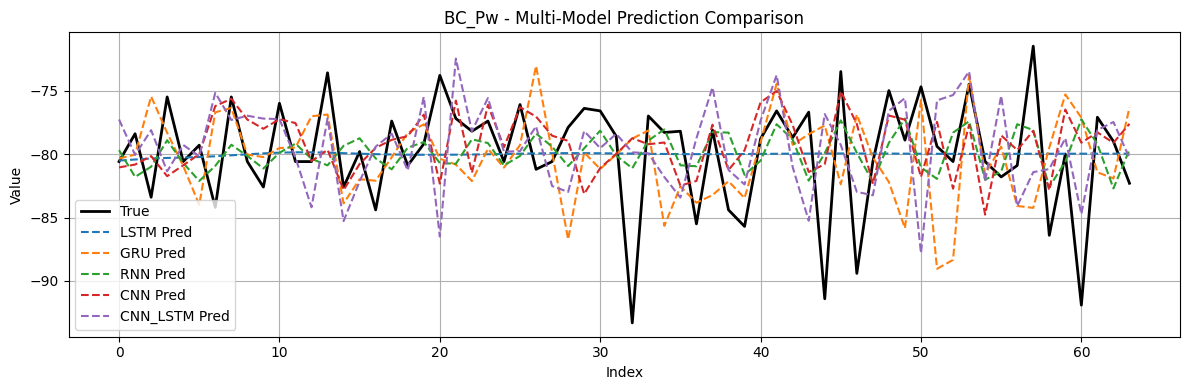

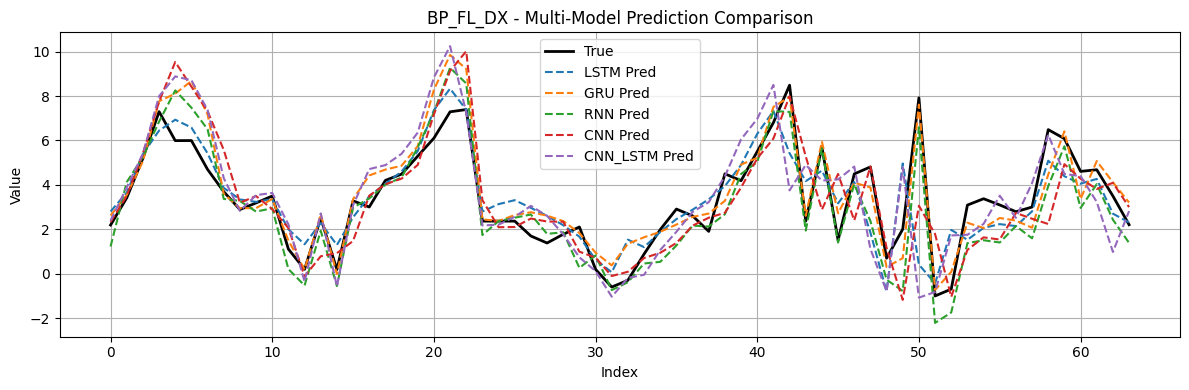

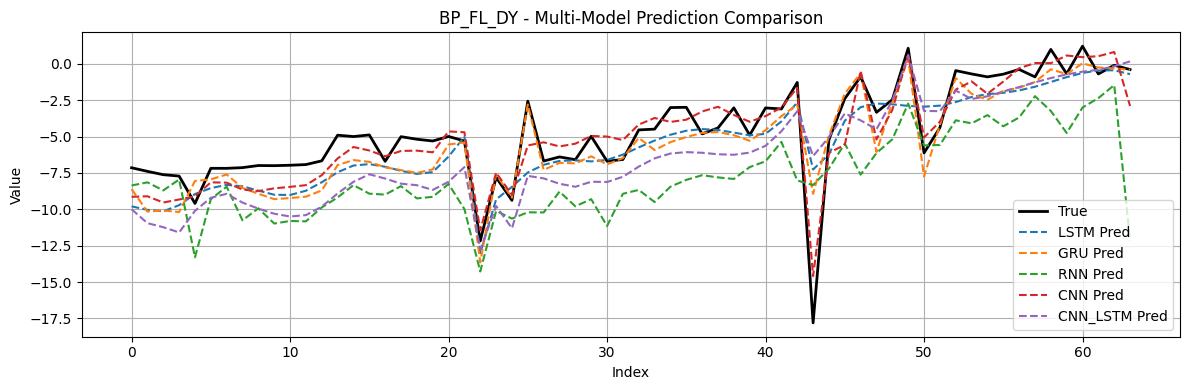

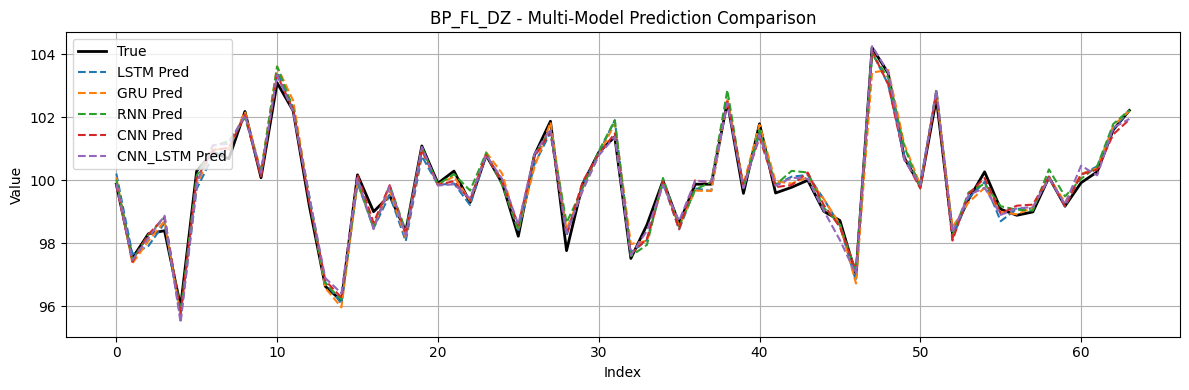

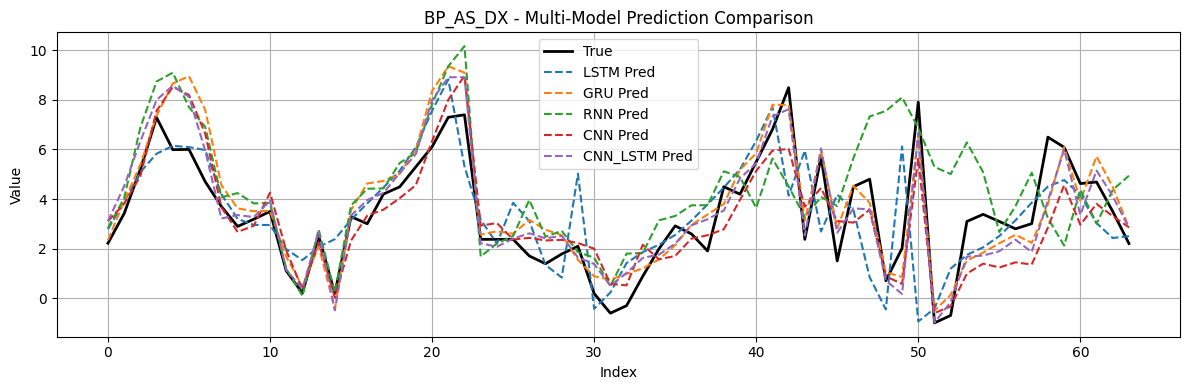

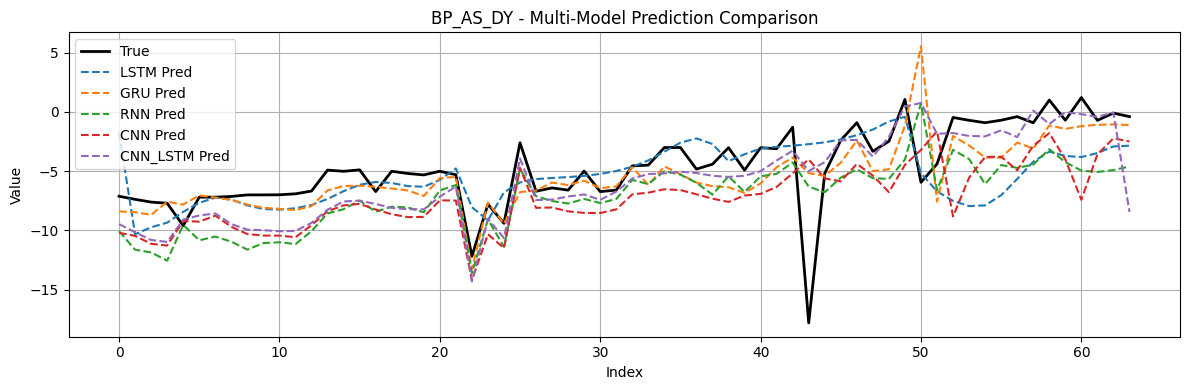

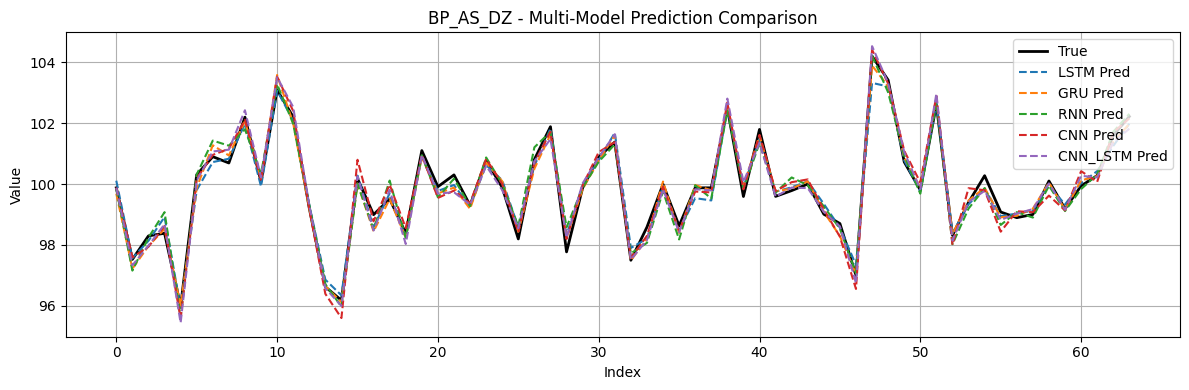

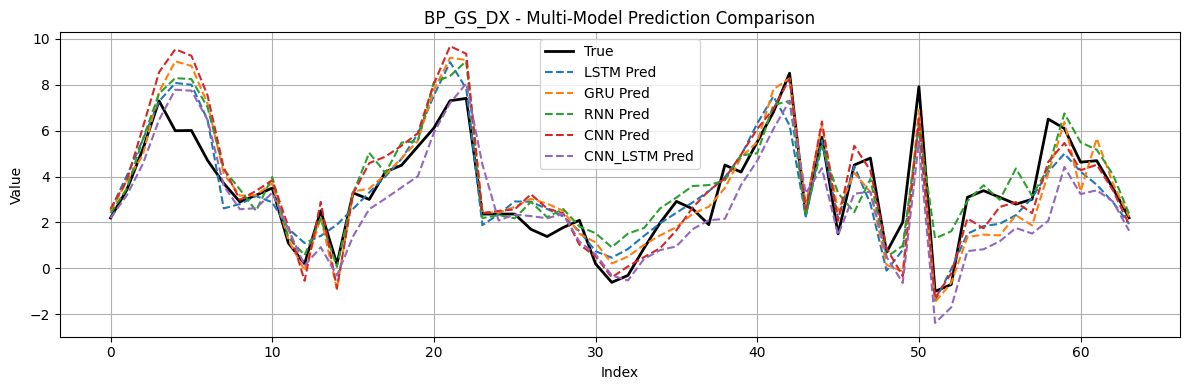

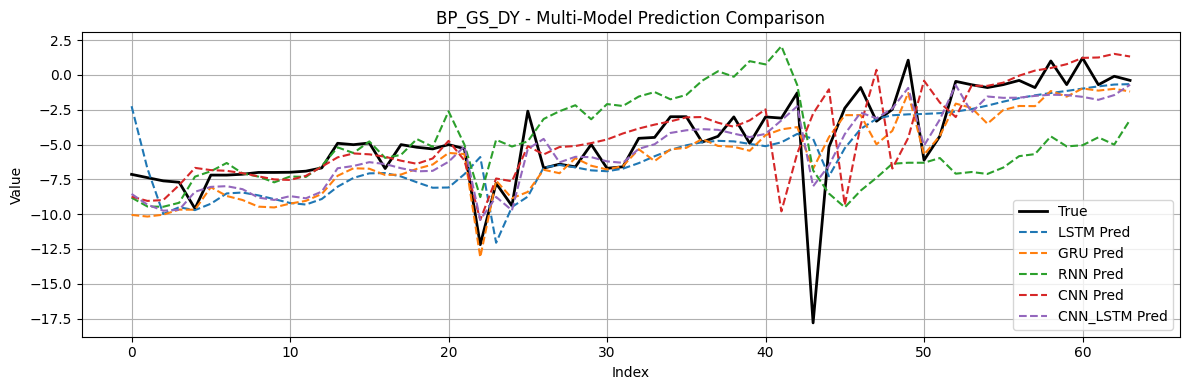

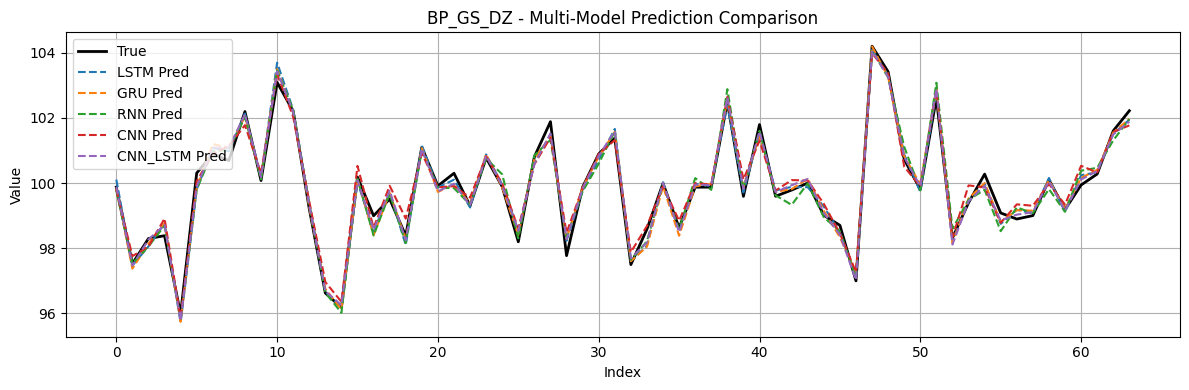

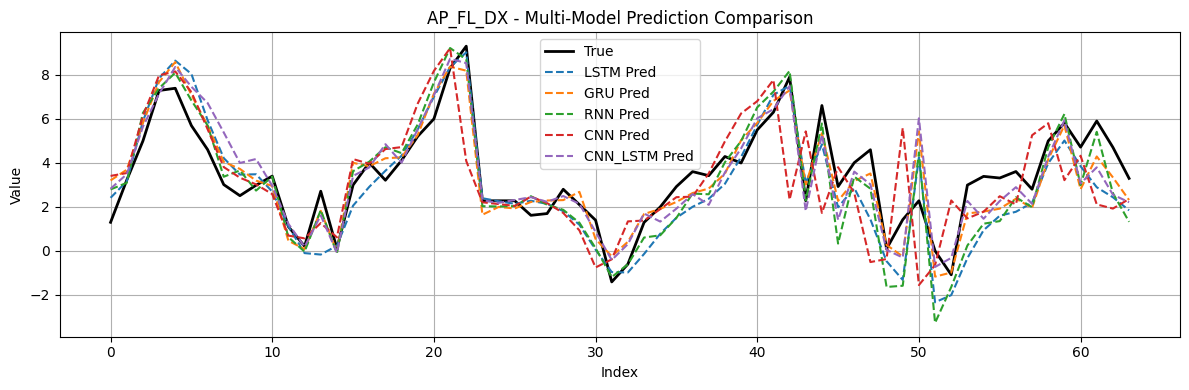

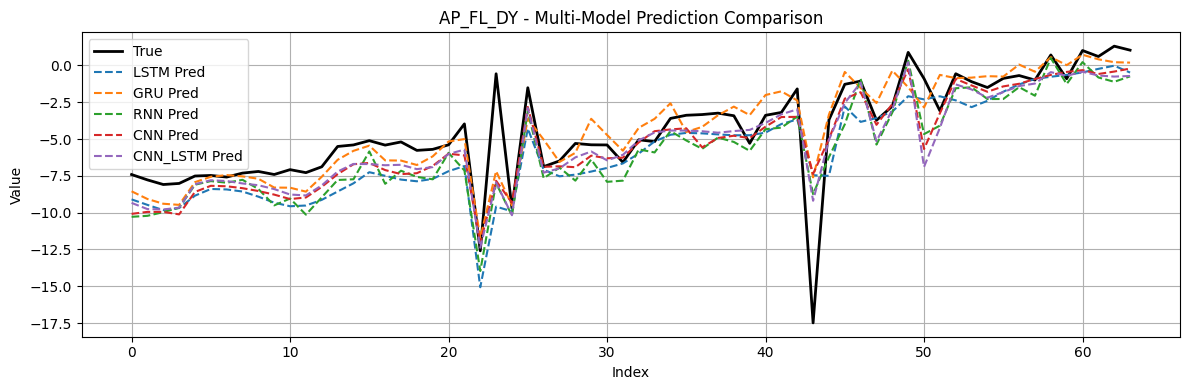

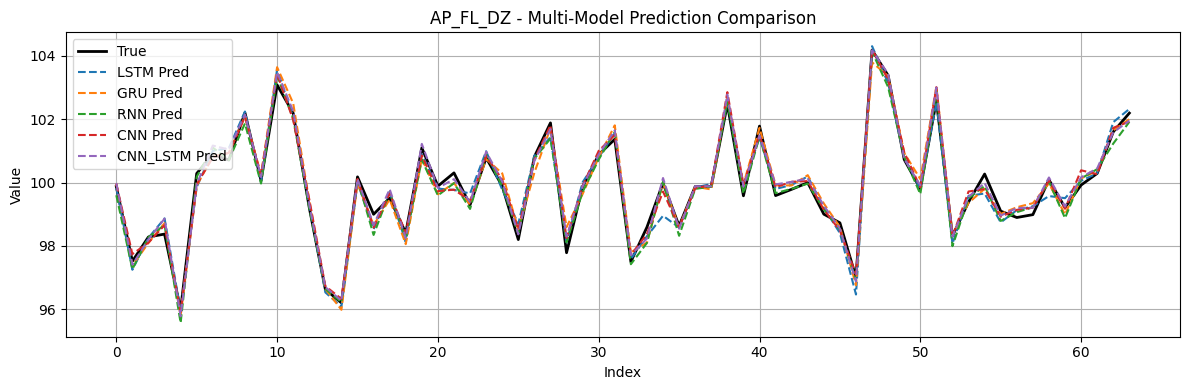

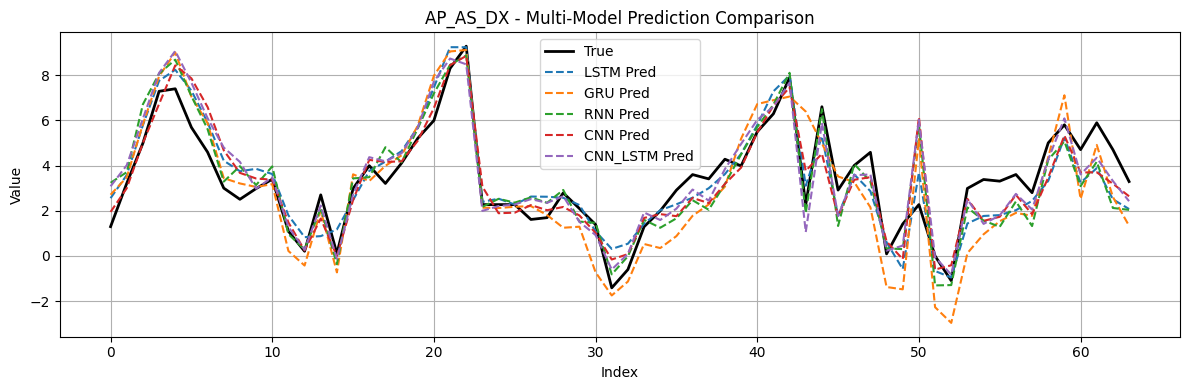

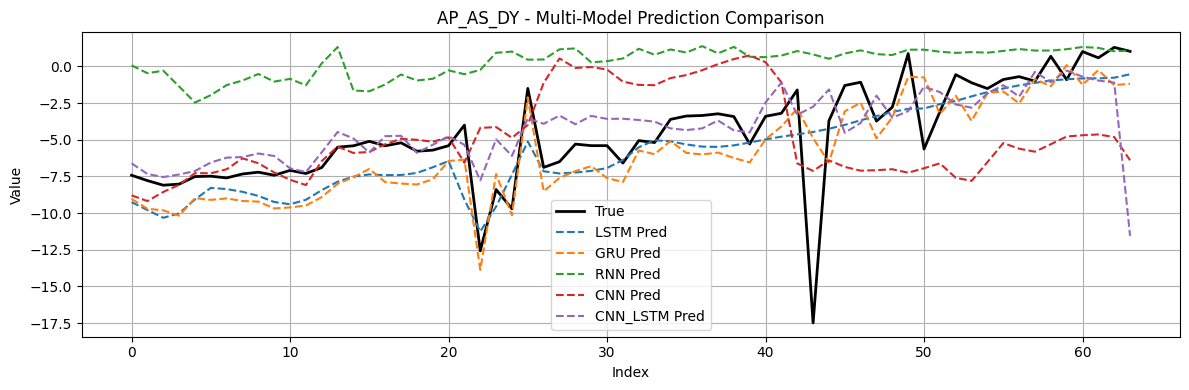

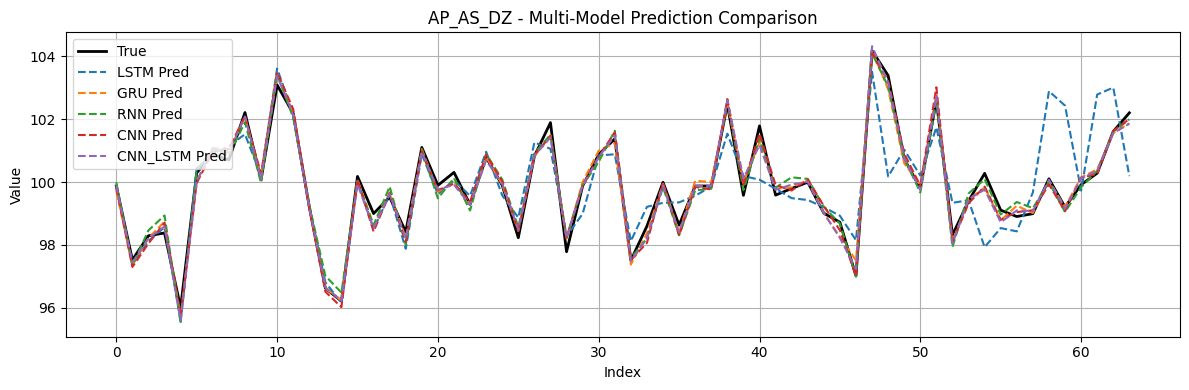

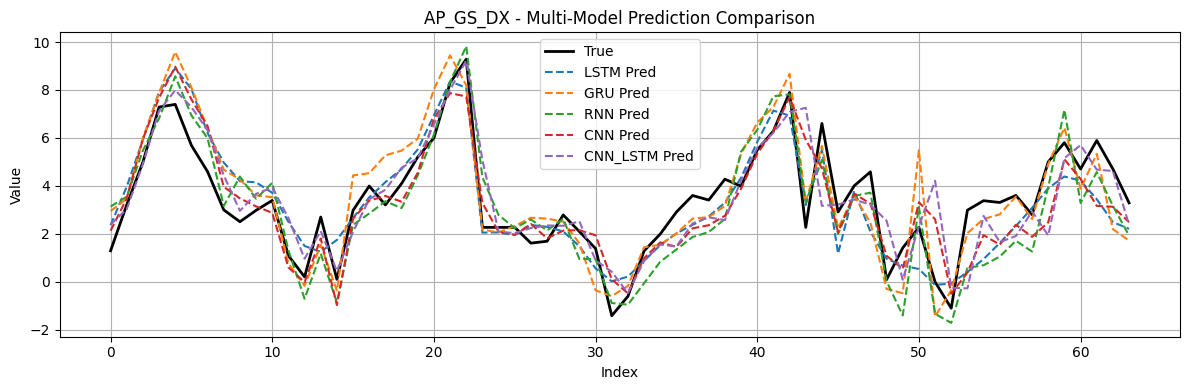

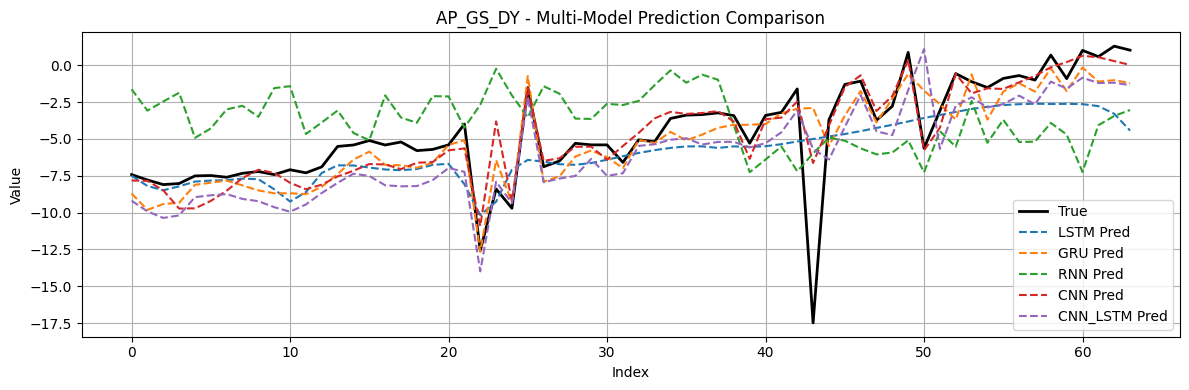

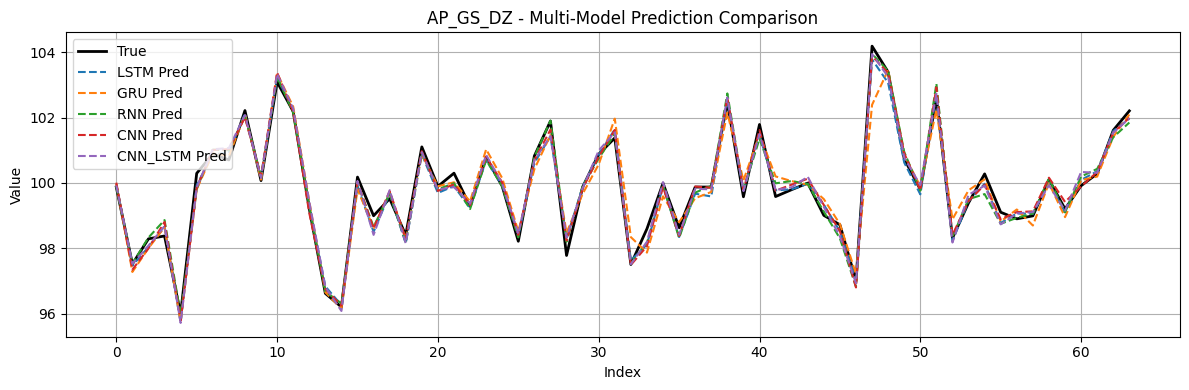

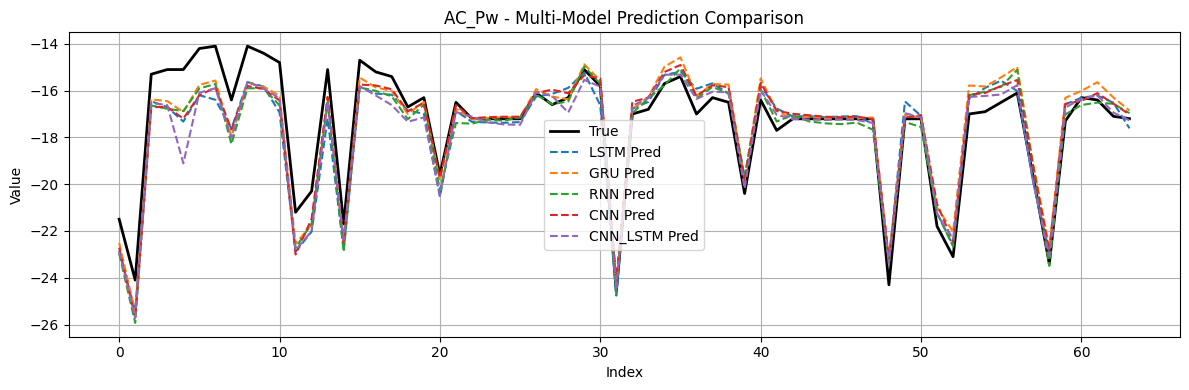

In [ ]:
# ========================
# 結果視覺化
# ========================
for col in columns:
    plt.figure(figsize=(12, 4))
    plt.title(f"{col} - Multi-Model Prediction Comparison")
    plt.plot(test_data[col][:64], label="True", linewidth=2, color="black")
    for model_type in MODEL_TYPES:
        if model_type in pred_dict[col]:
            plt.plot(pred_dict[col][model_type], label=model_type + " Pred", linestyle='--')
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# ========================
# 匯出結果
# ========================
df_export = pd.DataFrame(pred_dict[columns[0]])
df_export.to_csv(r"C:\Users\user\Desktop\ts\1010 outputs\\Col_A_predictions0804-02-1.csv", index=False)

metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.sort_values(by=["Column", "MAE"])
metrics_df.to_csv(r"C:\Users\user\Desktop\ts\1010 outputs\\Model_Metrics_Comparison0804-02-1.csv", index=False)
metrics_df


,Column,Model,MAE,MSE,CV,R2
59,AC_Pw,RNN,0.670529,0.788521,-0.047375,0.881236
79,AC_Pw,CNN,0.672894,0.765177,-0.049575,0.884752
99,AC_Pw,CNN_LSTM,0.686994,0.949370,-0.051895,0.857010
39,AC_Pw,GRU,0.689000,0.734065,-0.049099,0.889438
19,AC_Pw,LSTM,0.733782,0.917573,-0.052489,0.861799
...,...,...,...,...,...,...
89,BP_GS_DZ,CNN_LSTM,0.165507,0.042950,0.002075,0.984569
9,BP_GS_DZ,LSTM,0.183063,0.051864,0.002280,0.981366
29,BP_GS_DZ,GRU,0.183579,0.053915,0.002325,0.980629
49,BP_GS_DZ,RNN,0.215178,0.074256,0.002721,0.973321


In [ ]:
# ========================
# 推論時間統計工具函式
# ========================
def measure_inference_time(model, input_tensor, trials=30):
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(trials):
            start = time.time()
            _ = model(input_tensor)
            end = time.time()
            times.append((end - start) * 1000)  # 毫秒
    return np.mean(times), np.std(times)

# ========================
# R² 計算函式
# ========================
def compute_r2_score(y_true, y_pred):
    y_true = y_true.detach().cpu().numpy().flatten()
    y_pred = y_pred.detach().cpu().numpy().flatten()
    return r2_score(y_true, y_pred)

# ========================
# 匯出結果（加入 R² 與推論時間）
# ========================
df_export = pd.DataFrame(pred_dict[columns[0]])
df_export.to_csv(r"C:\Users\user\Desktop\ts\1010 outputs\\Col_A_predictions0804-03-1.csv", index=False)

metrics_df = pd.DataFrame(metrics)
if "Y_True" in metrics_df.columns and "Y_Pred" in metrics_df.columns:
    metrics_df["R2"] = metrics_df.apply(lambda row: compute_r2_score(row["Y_True"], row["Y_Pred"]), axis=1)
if "Model" in metrics_df.columns and "InputTensor" in metrics_df.columns:
    metrics_df["InferenceTime"] = metrics_df.apply(lambda row: measure_inference_time(create_model(row["Model"]).to(DEVICE), row["InputTensor"])[0], axis=1)

metrics_df = metrics_df.sort_values(by=["Column", "MAE"])
metrics_df.to_csv(r"C:\Users\user\Desktop\ts\1010 outputs\\Model_Metrics_Comparison0804-03-1.csv", index=False)
metrics_df

,Column,Model,MAE,MSE,CV,R2
59,AC_Pw,RNN,0.670529,0.788521,-0.047375,0.881236
79,AC_Pw,CNN,0.672894,0.765177,-0.049575,0.884752
99,AC_Pw,CNN_LSTM,0.686994,0.949370,-0.051895,0.857010
39,AC_Pw,GRU,0.689000,0.734065,-0.049099,0.889438
19,AC_Pw,LSTM,0.733782,0.917573,-0.052489,0.861799
...,...,...,...,...,...,...
89,BP_GS_DZ,CNN_LSTM,0.165507,0.042950,0.002075,0.984569
9,BP_GS_DZ,LSTM,0.183063,0.051864,0.002280,0.981366
29,BP_GS_DZ,GRU,0.183579,0.053915,0.002325,0.980629
49,BP_GS_DZ,RNN,0.215178,0.074256,0.002721,0.973321


In [ ]:
# ========================
# 評估與可視化（後續加入）
# ========================
def plot_predictions(test_seq, predictions, col_name):
    plt.figure(figsize=(12, 4))
    plt.plot(test_seq[:64], label="True", linewidth=2, color="black")
    for model_name, pred in predictions.items():
        plt.plot(pred, label=f"{model_name} Pred", linestyle="--")
    plt.title(f"Prediction Comparison - {col_name}")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_heatmap(results_df, metric):
    pivot = results_df.pivot(index="Column", columns="Model", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"{metric} Heatmap by Model")
    plt.tight_layout()
    plt.show()

def plot_radar(stats):
    categories = list(stats.keys())
    values = [stats[k] for k in categories]
    values += values[:1]  # close the loop
    categories += categories[:1]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, marker='o')
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles), categories)
    plt.title("Average Metric per Model")
    plt.show()
# ========================
# 推論時間統計工具函式
# ========================
def measure_inference_time(model, input_tensor, trials=30):
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(trials):
            start = time.time()
            _ = model(input_tensor)
            end = time.time()
            times.append((end - start) * 1000)  # 毫秒
    return np.mean(times), np.std(times)


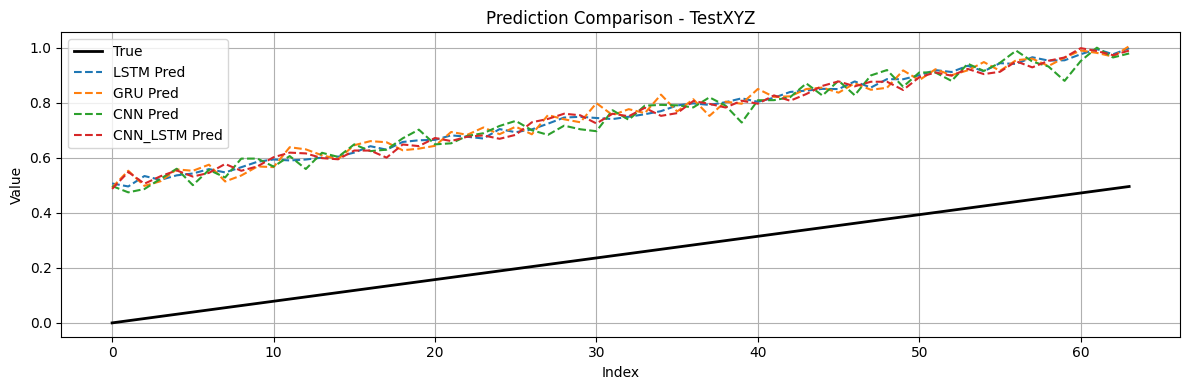

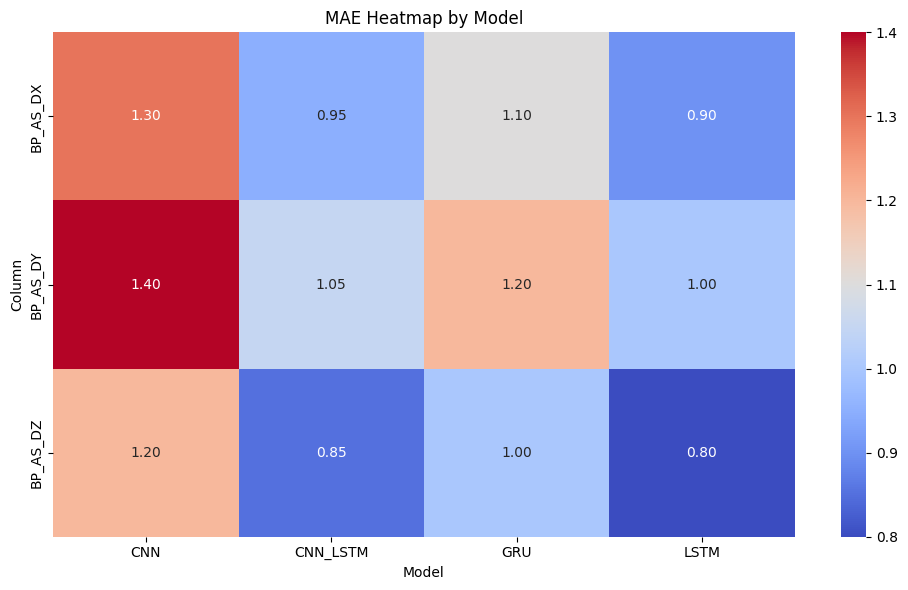

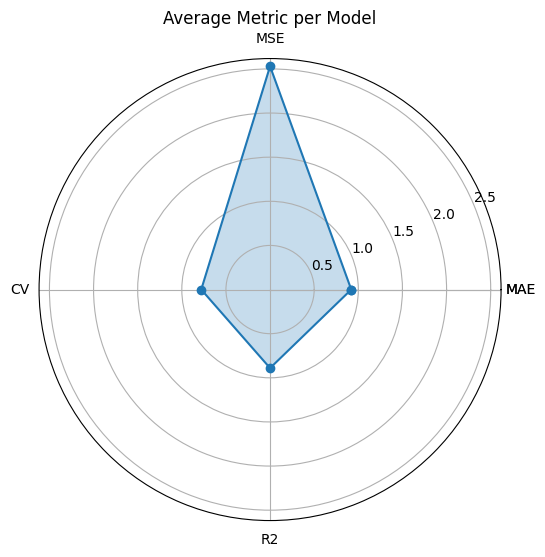

In [ ]:
# ========================
# 評估與可視化
# ========================
def plot_predictions(test_seq, predictions, col_name):
    plt.figure(figsize=(12, 4))
    plt.plot(test_seq[:64], label="True", linewidth=2, color="black")
    for model_name, pred in predictions.items():
        plt.plot(pred, label=f"{model_name} Pred", linestyle="--")
    plt.title(f"Prediction Comparison - {col_name}")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 測試資料與模擬預測
sample_seq = np.linspace(0, 1, 128)
sample_preds = {
    "LSTM": sample_seq[64:] + np.random.normal(0, 0.01, 64),
    "GRU": sample_seq[64:] + np.random.normal(0, 0.02, 64),
    "CNN": sample_seq[64:] + np.random.normal(0, 0.03, 64),
    "CNN_LSTM": sample_seq[64:] + np.random.normal(0, 0.015, 64),
}
plot_predictions(sample_seq, sample_preds, col_name="TestXYZ")

# 熱力圖（去除重複組合）
sample_df = pd.DataFrame({
    "Column": ["BP_AS_DX", "BP_AS_DY", "BP_AS_DZ"],
    "LSTM": [0.9, 1.0, 0.8],
    "GRU": [1.1, 1.2, 1.0],
    "CNN": [1.3, 1.4, 1.2],
    "CNN_LSTM": [0.95, 1.05, 0.85],
})

sample_df_melt = sample_df.melt(id_vars=["Column"], var_name="Model", value_name="MAE")

def plot_heatmap(results_df, metric):
    pivot = results_df.pivot(index="Column", columns="Model", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"{metric} Heatmap by Model")
    plt.tight_layout()
    plt.show()

plot_heatmap(sample_df_melt, metric="MAE")

# 雷達圖
sample_stats = {"MAE": 0.92, "MSE": 2.53, "CV": 0.78, "R2": 0.89}

def plot_radar(stats):
    categories = list(stats.keys())
    values = [stats[k] for k in categories]
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, marker='o')
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles), categories + [categories[0]])
    plt.title("Average Metric per Model")
    plt.show()

plot_radar(sample_stats)

# ========================
# 推論時間統計工具函式
# ========================
def measure_inference_time(model, input_tensor, trials=30):
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(trials):
            start = time.time()
            _ = model(input_tensor)
            end = time.time()
            times.append((end - start) * 1000)  # 毫秒
    return np.mean(times), np.std(times)

# ========================
# R² 計算函式
# ========================
def compute_r2_score(y_true, y_pred):
    y_true = y_true.detach().cpu().numpy().flatten()
    y_pred = y_pred.detach().cpu().numpy().flatten()
    return r2_score(y_true, y_pred)
